# Preprocessing Serangan DoS
Menyiapkan pipeline dari `dataset bnat.csv` agar siap dipakai untuk klasifikasi
Normal vs DoS tanpa menyimpan ke format parquet.

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

In [2]:
DATASET_FILENAME = "dataset bnat.csv"
LABELS_TO_KEEP = ["Normal", "DoS"]
LABEL_MAPPING = {"Normal": 0, "DoS": 1}
INV_LABEL_MAPPING = {v: k for k, v in LABEL_MAPPING.items()}
RANDOM_STATE = 42


def resolve_project_root(dataset_filename: str) -> Path:
    """Cari folder proyek yang menyimpan folder Dataset."""
    candidates = []
    if "__file__" in globals():
        candidates.append(Path(__file__).resolve().parent)
    candidates.append(Path.cwd())
    candidates.extend(parent for base in list(candidates) for parent in [base.parent])

    seen = []
    for base in candidates:
        base = base.resolve()
        if base in seen:
            continue
        seen.append(base)
        candidate_path = base / "Dataset" / dataset_filename
        if candidate_path.exists():
            return base

    search_locations = "\n".join(str(path) for path in seen)
    raise FileNotFoundError(
        f"Tidak menemukan '{dataset_filename}' pada lokasi berikut:\n{search_locations}"
    )


PROJECT_ROOT = resolve_project_root(DATASET_FILENAME)
DATASET_PATH = PROJECT_ROOT / "Dataset" / DATASET_FILENAME
ARTIFACTS_DIR = PROJECT_ROOT / "Preprocessing" / "artifacts"

pd.set_option("display.max_columns", 25)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
plt.style.use("ggplot")


def plot_label_distribution(df: pd.DataFrame, title: str) -> None:
    """Visual helper to inspect distribusi label pada setiap tahapan."""
    counts = df["label"].value_counts().sort_index()
    ax = counts.plot(kind="bar", color="#1f77b4", figsize=(6, 4), rot=0, title=title)
    for idx, value in enumerate(counts):
        ax.text(idx, value, f"{int(value)}", ha="center", va="bottom")
    ax.set_ylabel("Jumlah sampel")
    plt.tight_layout()
    plt.show()


def plot_split_sizes(y_train: pd.Series, y_test: pd.Series, title: str) -> None:
    """Menampilkan komposisi train/test secara visual."""
    sizes = pd.Series({"Train": len(y_train), "Test": len(y_test)})
    ax = sizes.plot(kind="bar", color=["#2ca02c", "#d62728"], rot=0, title=title)
    for idx, value in enumerate(sizes):
        ax.text(idx, value, f"{int(value)}", ha="center", va="bottom")
    ax.set_ylabel("Jumlah sampel")
    plt.tight_layout()
    plt.show()

Bentuk awal dataset: (165000, 22)
Preview data awal (tabel penuh):
 duration protocol_type service  src_bytes  dst_bytes flag  count  srv_count  serror_rate  same_srv_rate  diff_srv_rate  srv_serror_rate  srv_diff_host_rate  dst_host_count  dst_host_srv_count  dst_host_same_srv_rate  dst_host_diff_srv_rate  dst_host_same_src_port_rate  dst_host_serror_rate  dst_host_srv_diff_host_rate  dst_host_srv_serror_rate  label
        0           tcp   other         66          0  OTH      5         15          0.0           1.00           0.00              0.0                0.67               5                  15                    1.00                    0.00                         0.31                   0.0                         0.67                       0.0 Normal
        0           tcp   other         66          0  OTH   1045       2549          0.0           1.00           0.00              0.0                0.59              50                  96                    1.00         

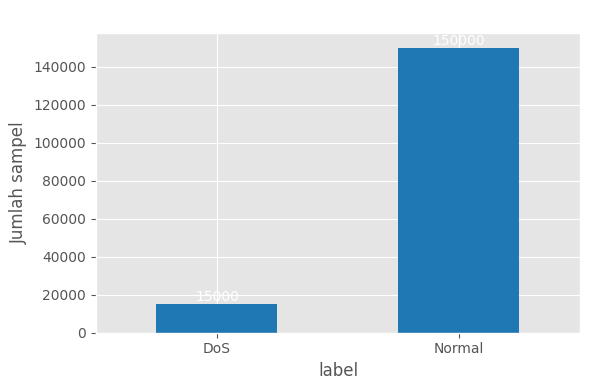

In [4]:
df_raw = pd.read_csv(DATASET_PATH)
print(f"Bentuk awal dataset: {df_raw.shape}")
print("Preview data awal (tabel penuh):")
print(df_raw.head().to_string(index=False))
plot_label_distribution(df_raw, "Distribusi Label - Dataset Awal")

In [5]:
# Hapus duplikat terlebih dahulu sesuai instruksi
df_dedup = df_raw.drop_duplicates().reset_index(drop=True)
removed_duplicates = len(df_raw) - len(df_dedup)
print(f"Jumlah baris duplikat yang dihapus: {removed_duplicates}")
print(f"Bentuk setelah deduplikasi: {df_dedup.shape}")

Jumlah baris duplikat yang dihapus: 71330
Bentuk setelah deduplikasi: (93670, 22)


Distribusi label (dataset sudah berisi Normal & DoS saja):
label
Normal    78919
DoS       14751
Name: count, dtype: int64


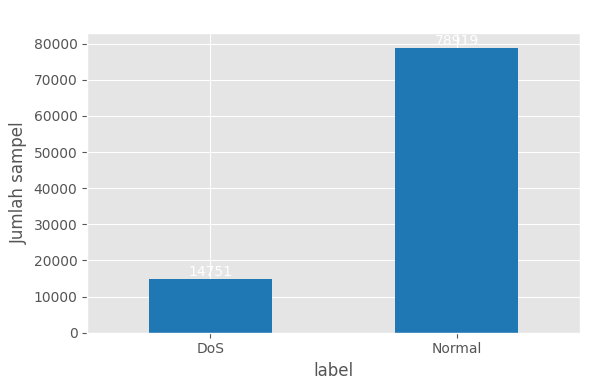

In [6]:
# Dataset sudah Normal & DoS; gunakan distribusi aslinya tanpa sampling ulang
print("Distribusi label (dataset sudah berisi Normal & DoS saja):")
print(df_dedup["label"].value_counts())
plot_label_distribution(
    df_dedup, "Distribusi Label - Setelah Deduplikasi (Normal & DoS)"
)

In [7]:
# Pisahkan fitur dan label untuk proses selanjutnya
X = df_dedup.drop(columns=["label"])
y = df_dedup["label"].map({"Normal": 0, "DoS": 1})

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X.select_dtypes(exclude=["object"]).columns.tolist()

print(f"Fitur kategorikal ({len(categorical_features)} kolom): {categorical_features}")
print(f"Fitur numerik ({len(numeric_features)} kolom): {numeric_features}")
print("Distribusi kategori awal:")
for cat_col in categorical_features:
    print(f"- {cat_col}: {X[cat_col].value_counts().to_dict()}")

# Simpan urutan kategori sesuai kemunculan awal agar encoding konsisten
categorical_categories = [
    X[col].dropna().astype(str).unique().tolist() for col in categorical_features
]


def get_categorical_mappings(
    encoder: OrdinalEncoder, columns: list[str]
) -> dict[str, dict]:
    """
    Utility untuk menampilkan mapping kategori -> angka dari OrdinalEncoder.
    """
    mappings = {}
    category_lists = getattr(encoder, "categories_", None)
    if category_lists is None:
        print("OrdinalEncoder belum dilatih; mapping tidak tersedia.")
        return mappings
    for col, categories in zip(columns, category_lists):
        mappings[col] = {
            category: int(idx) for idx, category in enumerate(list(categories))
        }
    return mappings

Fitur kategorikal (3 kolom): ['protocol_type', 'service', 'flag']
Fitur numerik (18 kolom): ['duration', 'src_bytes', 'dst_bytes', 'count', 'srv_count', 'serror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_serror_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_serror_rate', 'dst_host_srv_diff_host_rate', 'dst_host_srv_serror_rate']
Distribusi kategori awal:
- protocol_type: {'tcp': 93644, 'udp': 24, 'icmp': 2}
- service: {'other': 50271, 'http': 42293, 'private': 1102, 'netbios_ssn': 2, 'oth_i': 2}
- flag: {'OTH': 71295, 'S1': 15304, 'SF': 6991, 'S3': 80}


Train size: (74936, 21), Test size: (18734, 21)
Distribusi label pada train: {0: 63135, 1: 11801}
Distribusi label pada test: {0: 15784, 1: 2950}


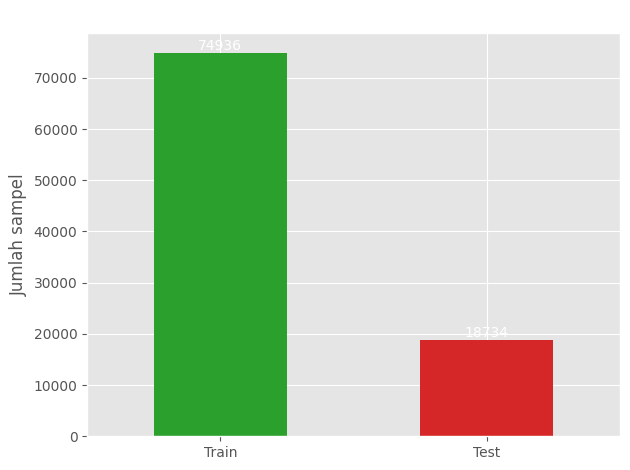

In [8]:
# Split train-test agar siap dipakai model
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")
print("Distribusi label pada train:", y_train.value_counts().to_dict())
print("Distribusi label pada test:", y_test.value_counts().to_dict())
plot_split_sizes(y_train, y_test, "Proporsi Data Train vs Test")

In [9]:
# Pipeline preprocessing: scale numerik + ordinal encode kategorikal
column_transformer = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        (
            "categorical",
            OrdinalEncoder(
                categories=categorical_categories,
                handle_unknown="use_encoded_value",
                unknown_value=-1,
                dtype=float,
            ),
            categorical_features,
        ),
    ],
    remainder="drop",
    sparse_threshold=0,
)

preprocessing_pipeline = Pipeline(
    steps=[
        ("features", column_transformer),
    ]
)

In [10]:
# Fit-transform untuk mendapatkan data siap pakai model
X_train_prepared = preprocessing_pipeline.fit_transform(X_train)
X_test_prepared = preprocessing_pipeline.transform(X_test)

feature_names = numeric_features + categorical_features

print(f"Shape X_train setelah preprocessing: {X_train_prepared.shape}")
print(f"Shape X_test setelah preprocessing: {X_test_prepared.shape}")
print(f"Jumlah fitur setelah encoding: {len(feature_names)}")
print("Preview fitur hasil preprocessing (5 baris pertama):")
X_train_preview = pd.DataFrame(
    X_train_prepared[:5],
    columns=feature_names,
)
print(X_train_preview.to_string(index=False))

# Tampilkan mapping kategori -> angka setelah fit encoder
encoder = preprocessing_pipeline.named_steps["features"].named_transformers_[
    "categorical"
]
cat_mappings = get_categorical_mappings(encoder, categorical_features)
print("Mapping kategori -> angka:")
for col, mapping in cat_mappings.items():
    print(f"- {col}: {mapping}")

Shape X_train setelah preprocessing: (74936, 21)
Shape X_test setelah preprocessing: (18734, 21)
Jumlah fitur setelah encoding: 21
Preview fitur hasil preprocessing (5 baris pertama):
 duration  src_bytes  dst_bytes     count  srv_count  serror_rate  same_srv_rate  diff_srv_rate  srv_serror_rate  srv_diff_host_rate  dst_host_count  dst_host_srv_count  dst_host_same_srv_rate  dst_host_diff_srv_rate  dst_host_same_src_port_rate  dst_host_serror_rate  dst_host_srv_diff_host_rate  dst_host_srv_serror_rate  protocol_type  service  flag
-0.003653  -0.510567  -0.144711 -0.558241  -0.487930    -0.423317       0.529053      -0.527486        -0.419505            0.370523       -0.324005            0.124718                0.507059               -0.501551                    -0.641364             -0.427652                     0.395102                 -0.425834            0.0      0.0   0.0
-0.003653  -0.534800  -0.144711  0.574601   0.201794     1.878961       0.484615      -0.481643         1.6547

In [11]:
# Variabel akhir yang bisa digunakan di notebook / eksperimen model
artifacts = {
    "df_dedup": df_dedup,
    "X_train_prepared": X_train_prepared,
    "X_test_prepared": X_test_prepared,
    "y_train": y_train,
    "y_test": y_test,
    "feature_names": feature_names,
    "preprocessing_pipeline": preprocessing_pipeline,
}
print("Artifacts siap digunakan:", list(artifacts.keys()))

Artifacts siap digunakan: ['df_dedup', 'X_train_prepared', 'X_test_prepared', 'y_train', 'y_test', 'feature_names', 'preprocessing_pipeline']


In [12]:
# Simpan scaler + encoder (pipeline) serta hasil split agar mudah dipakai saat testing
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

PIPELINE_PATH = ARTIFACTS_DIR / "preprocessing_pipeline.joblib"
SPLIT_PATH = ARTIFACTS_DIR / "prepared_split.joblib"

joblib.dump(preprocessing_pipeline, PIPELINE_PATH)
joblib.dump(
    {
        "X_train_prepared": X_train_prepared,
        "X_test_prepared": X_test_prepared,
        "y_train": y_train,
        "y_test": y_test,
        "feature_names": feature_names,
    },
    SPLIT_PATH,
)

print(f"Pipeline tersimpan di: {PIPELINE_PATH.resolve()}")
print(f"Data split tersimpan di: {SPLIT_PATH.resolve()}")

Pipeline tersimpan di: D:\Ppo\Preprocessing\artifacts\preprocessing_pipeline.joblib
Data split tersimpan di: D:\Ppo\Preprocessing\artifacts\prepared_split.joblib
